In [1]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

SR = 1024            # iEEG sample rate (Hz)
F_CUT = 10.0         # cutoff used in the new pipeline (Hz)
WIN_MS = 50          # old Hilbert path's window length (ms)
N_BUTTER = 4         # filter order

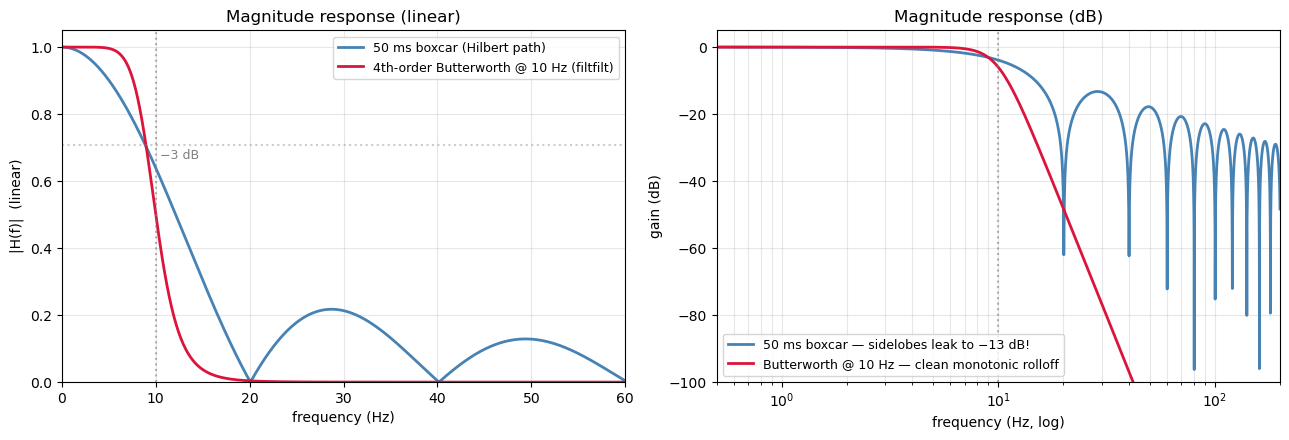

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — The actual swap: Butterworth-10 Hz vs 50 ms boxcar
# ═══════════════════════════════════════════════════════════════════════════════
# Butterworth 4th order, applied with filtfilt in the pipeline → magnitude
# response is squared, hence the *2 in dB.
sos_butter = scipy.signal.iirfilter(N_BUTTER, F_CUT/(SR/2),
                                    btype='lowpass', output='sos')
w, h_butter = scipy.signal.sosfreqz(sos_butter, worN=8192, fs=SR)
mag_butter_filtfilt_db = 20*np.log10(np.abs(h_butter)**2 + 1e-15)

# Boxcar (rectangular window) — the implicit smoother in the Hilbert path.
n_box = int(WIN_MS/1000 * SR)
b_box = np.ones(n_box)/n_box
w_box, h_box = scipy.signal.freqz(b_box, [1.0], worN=8192, fs=SR)
mag_box_db = 20*np.log10(np.abs(h_box) + 1e-15)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Linear y, zoomed to passband+transition
ax = axes[0]
ax.plot(w_box, np.abs(h_box), lw=2, color='steelblue',
        label=f'{WIN_MS} ms boxcar (Hilbert path)')
ax.plot(w, np.abs(h_butter)**2, lw=2, color='crimson',
        label=f'{N_BUTTER}th-order Butterworth @ {F_CUT:.0f} Hz (filtfilt)')
ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
ax.axhline(np.sqrt(0.5), color='gray', ls=':', alpha=0.4)
ax.text(F_CUT+0.5, np.sqrt(0.5)-0.04, '−3 dB', color='gray', fontsize=9)
ax.set_xlim(0, 60); ax.set_ylim(0, 1.05)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('|H(f)|  (linear)')
ax.set_title('Magnitude response (linear)')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# Log y, full picture
ax = axes[1]
ax.plot(w_box, mag_box_db, lw=2, color='steelblue',
        label=f'{WIN_MS} ms boxcar — sidelobes leak to −13 dB!')
ax.plot(w, mag_butter_filtfilt_db, lw=2, color='crimson',
        label=f'Butterworth @ {F_CUT:.0f} Hz — clean monotonic rolloff')
ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
ax.set_xscale('log')
ax.set_xlim(0.5, 200); ax.set_ylim(-100, 5)
ax.set_xlabel('frequency (Hz, log)'); ax.set_ylabel('gain (dB)')
ax.set_title('Magnitude response (dB)')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

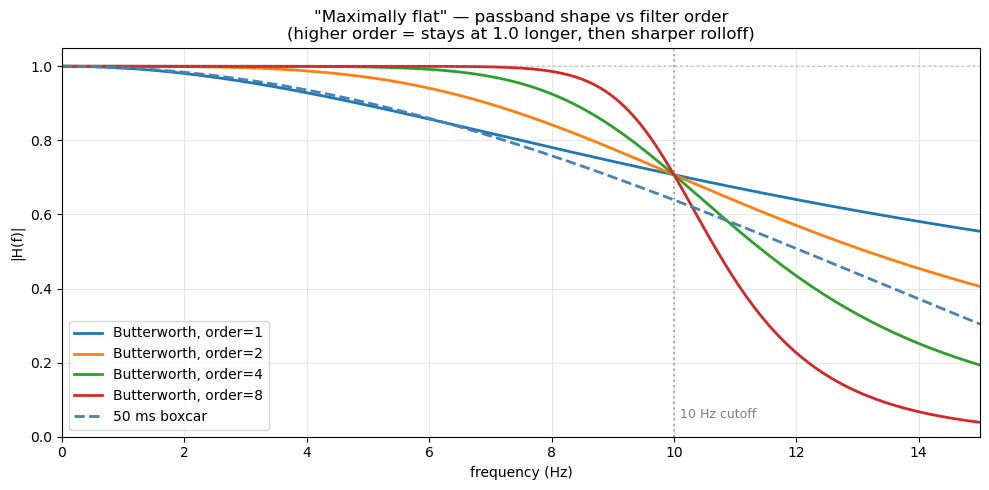

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — "Maximally flat": passband zoom (0–10 Hz)
# ═══════════════════════════════════════════════════════════════════════════════
# Mathematical definition: Butterworth is the unique filter where the first
# 2N−1 derivatives of |H(f)|² are zero at f=0.  Translation: the passband
# is as FLAT as it can possibly be — it stays at 1.0 longer than any other
# filter family before starting to roll off.  No ripples, no overshoot.
#
# The plot below zooms into the passband only (0–10 Hz) so you can see the
# shape near DC.  Notice how the Butterworth hugs 1.0 across most of the
# passband, then bends down as it approaches the cutoff.

orders = [1, 2, 4, 8]   # ← play with these to see the effect of order
fig, ax = plt.subplots(figsize=(10, 5))

for n in orders:
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')
    w, h = scipy.signal.sosfreqz(sos, worN=8192, fs=SR)
    ax.plot(w, np.abs(h), lw=2, label=f'Butterworth, order={n}')

# A boxcar for comparison — same passband region
ax.plot(w_box, np.abs(h_box), lw=2, color='steelblue', ls='--',
        label=f'{WIN_MS} ms boxcar')

ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
ax.text(F_CUT+0.1, 0.05, '10 Hz cutoff', color='gray', fontsize=9)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.set_xlim(0, 15); ax.set_ylim(0, 1.05)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('|H(f)|')
ax.set_title('"Maximally flat" — passband shape vs filter order\n'
             '(higher order = stays at 1.0 longer, then sharper rolloff)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


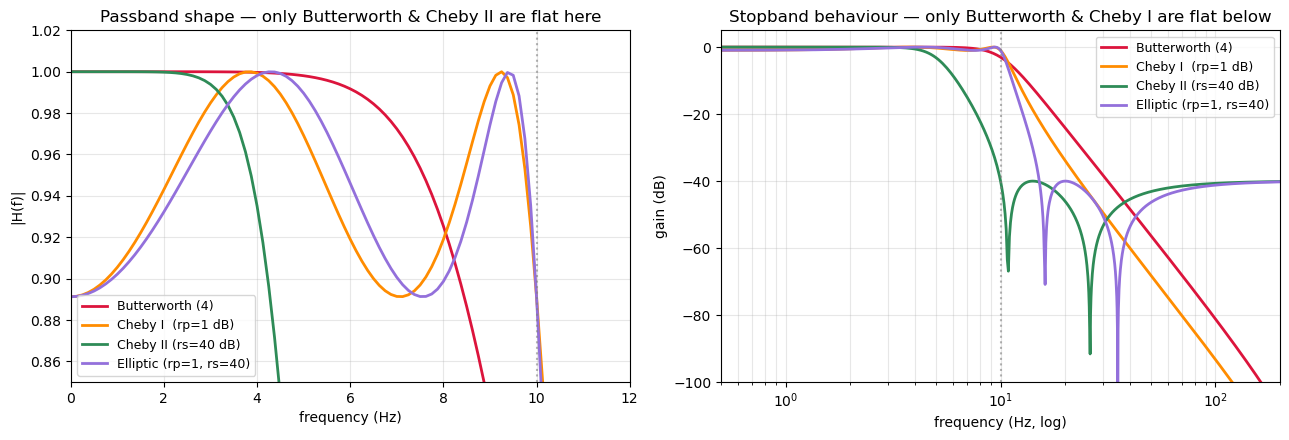

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Butterworth vs other classical IIR filters
# ═══════════════════════════════════════════════════════════════════════════════
# Each filter family is a different point in the trade-off space:
#
#   Butterworth   — flat passband, flat stopband, gentle rolloff   ← we picked this
#   Chebyshev I   — flat stopband,  RIPPLES in passband, faster rolloff
#   Chebyshev II  — flat passband,  RIPPLES in stopband, faster rolloff
#   Elliptic      — RIPPLES in both, fastest rolloff, smallest order
#
# Phoneme rate (5–10 Hz) sits right at the edge of our passband.  Ripples
# in the passband would be unacceptable — they'd modulate the envelope at
# the very frequencies we care about.  That's why Butterworth wins for
# this application even though Elliptic has steeper transition.

freq = np.linspace(0.01, 60, 4000)

filters = []

# Butterworth (no ripple)
sos_b   = scipy.signal.iirfilter(4, F_CUT/(SR/2), btype='lowpass', output='sos')
_, h_b  = scipy.signal.sosfreqz(sos_b, worN=4096, fs=SR)
filters.append(('Butterworth (4)',         'crimson',     h_b))

# Chebyshev I — passband ripples
sos_c1  = scipy.signal.iirfilter(4, F_CUT/(SR/2), btype='lowpass',
                                 ftype='cheby1', rp=1.0, output='sos')
_, h_c1 = scipy.signal.sosfreqz(sos_c1, worN=4096, fs=SR)
filters.append(('Cheby I  (rp=1 dB)',      'darkorange',  h_c1))

# Chebyshev II — stopband ripples
sos_c2  = scipy.signal.iirfilter(4, F_CUT/(SR/2), btype='lowpass',
                                 ftype='cheby2', rs=40,  output='sos')
_, h_c2 = scipy.signal.sosfreqz(sos_c2, worN=4096, fs=SR)
filters.append(('Cheby II (rs=40 dB)',     'seagreen',    h_c2))

# Elliptic — ripples in both
sos_el  = scipy.signal.iirfilter(4, F_CUT/(SR/2), btype='lowpass',
                                 ftype='ellip', rp=1.0, rs=40, output='sos')
_, h_el = scipy.signal.sosfreqz(sos_el, worN=4096, fs=SR)
filters.append(('Elliptic (rp=1, rs=40)',  'mediumpurple',h_el))

w, _ = scipy.signal.sosfreqz(sos_b, worN=4096, fs=SR)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Linear, passband zoom
ax = axes[0]
for name, color, h in filters:
    ax.plot(w, np.abs(h), lw=2, color=color, label=name)
ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
ax.set_xlim(0, 12); ax.set_ylim(0.85, 1.02)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('|H(f)|')
ax.set_title('Passband shape — only Butterworth & Cheby II are flat here')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='lower left')

# dB, full picture
ax = axes[1]
for name, color, h in filters:
    ax.plot(w, 20*np.log10(np.abs(h)+1e-15), lw=2, color=color, label=name)
ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
ax.set_xscale('log')
ax.set_xlim(0.5, 200); ax.set_ylim(-100, 5)
ax.set_xlabel('frequency (Hz, log)'); ax.set_ylabel('gain (dB)')
ax.set_title('Stopband behaviour — only Butterworth & Cheby I are flat below')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

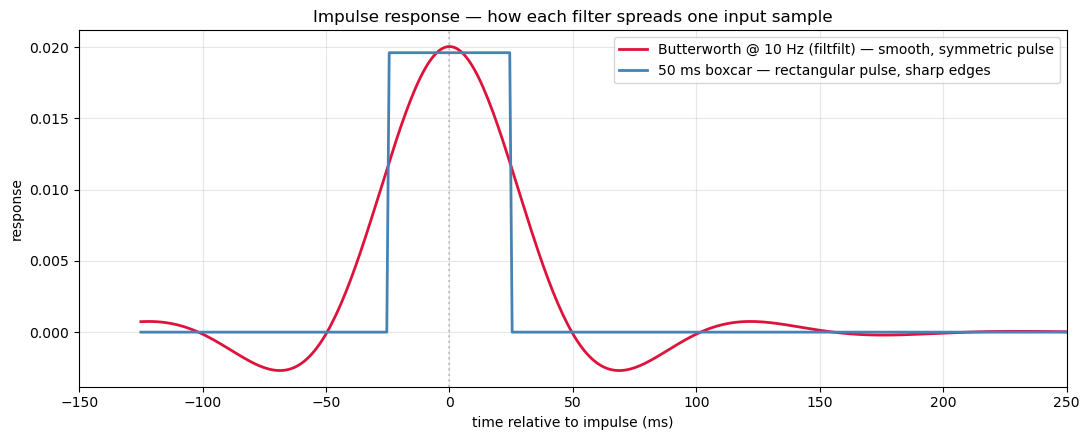

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Impulse response: what does the filter do to a single spike?
# ═══════════════════════════════════════════════════════════════════════════════
# This is the time-domain dual of the frequency response.  It tells you
# how the filter "smears" each input sample into the output.

duration = 0.5   # seconds for the impulse response window
n_imp    = int(duration*SR)
impulse  = np.zeros(n_imp); impulse[n_imp//4] = 1.0    # delta at t = duration/4
t_imp    = (np.arange(n_imp) - n_imp//4) / SR * 1000   # ms, 0 = impulse

# Butterworth response (filtfilt — zero-phase, so it's symmetric in time)
y_butter = scipy.signal.sosfiltfilt(sos_butter, impulse)

# Boxcar response = the filter kernel itself
y_box = np.convolve(impulse, b_box, mode='same')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_imp, y_butter, lw=2, color='crimson',
        label='Butterworth @ 10 Hz (filtfilt) — smooth, symmetric pulse')
ax.plot(t_imp, y_box,    lw=2, color='steelblue',
        label=f'{WIN_MS} ms boxcar — rectangular pulse, sharp edges')
ax.axvline(0, color='gray', ls=':', alpha=0.4)
ax.set_xlim(-150, 250)
ax.set_xlabel('time relative to impulse (ms)')
ax.set_ylabel('response')
ax.set_title('Impulse response — how each filter spreads one input sample')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


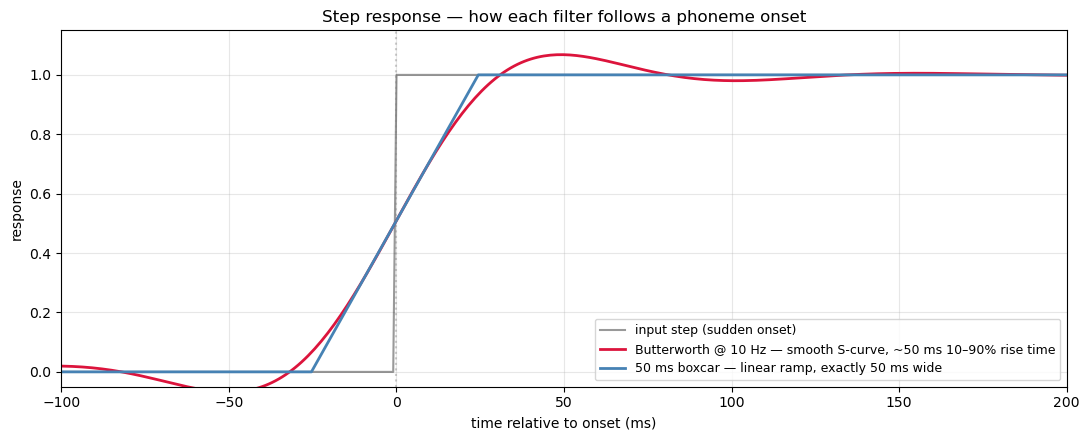

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Step response: what happens at a sudden onset (phoneme transition)
# ═══════════════════════════════════════════════════════════════════════════════
# A phoneme onset looks roughly like a step in the envelope: low → high.
# This panel shows how each filter handles that step.  The Butterworth has
# a smooth S-curve; the boxcar has a linear ramp.

n_step = int(0.5 * SR)
step   = np.zeros(n_step)
step[n_step//2:] = 1.0
t_step = (np.arange(n_step) - n_step//2) / SR * 1000   # ms, 0 = step onset

y_butter_step = scipy.signal.sosfiltfilt(sos_butter, step)
y_box_step    = np.convolve(step, b_box, mode='same')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_step, step, lw=1.5, color='black', alpha=0.4,
        label='input step (sudden onset)')
ax.plot(t_step, y_butter_step, lw=2, color='crimson',
        label='Butterworth @ 10 Hz — smooth S-curve, ~50 ms 10–90% rise time')
ax.plot(t_step, y_box_step,    lw=2, color='steelblue',
        label=f'{WIN_MS} ms boxcar — linear ramp, exactly {WIN_MS} ms wide')
ax.axvline(0, color='gray', ls=':', alpha=0.4)
ax.set_xlim(-100, 200); ax.set_ylim(-0.05, 1.15)
ax.set_xlabel('time relative to onset (ms)')
ax.set_ylabel('response')
ax.set_title('Step response — how each filter follows a phoneme onset')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


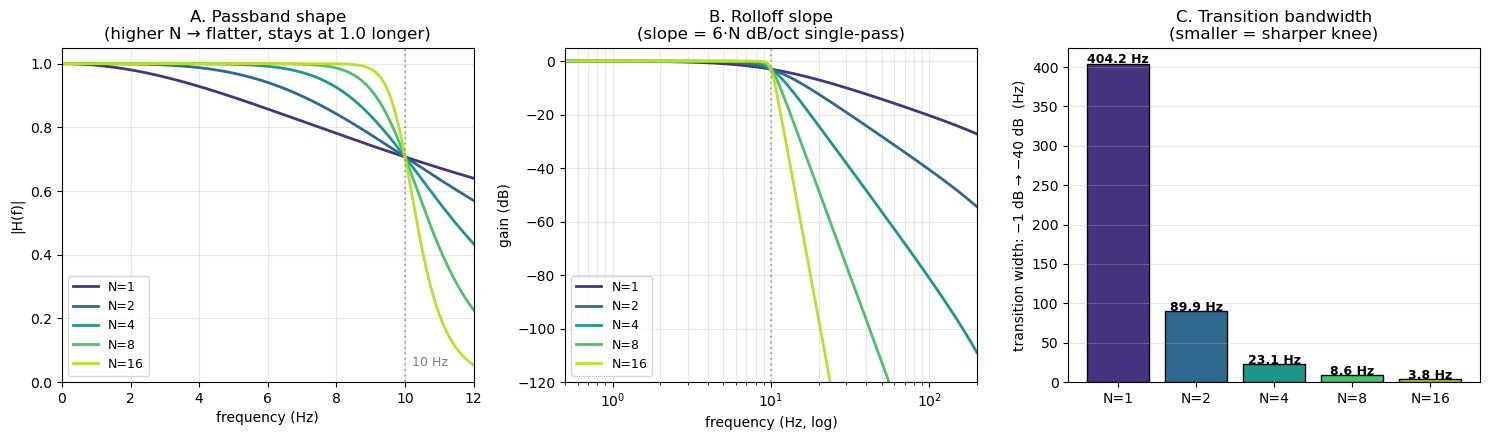

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Order comparison: frequency response across N = 1, 2, 4, 8, 16
# ═══════════════════════════════════════════════════════════════════════════════
# Three things change with the order N of a Butterworth filter:
#
#   1.  Passband flatness    — higher N stays at gain 1.0 longer near DC
#   2.  Transition sharpness — higher N has a narrower "knee" near cutoff
#   3.  Stopband rolloff     — higher N drops faster: 6·N dB/octave (single pass)
#                                                   12·N dB/octave with filtfilt
#
# Pipeline default is N=4 with filtfilt → 48 dB/oct effective rolloff.

orders_to_compare = [1, 2, 4, 8, 16]
colors_order = plt.cm.viridis(np.linspace(0.15, 0.9, len(orders_to_compare)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel A — passband zoom (linear)
ax = axes[0]
for n, c in zip(orders_to_compare, colors_order):
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')
    w, h = scipy.signal.sosfreqz(sos, worN=8192, fs=SR)
    ax.plot(w, np.abs(h), lw=2, color=c, label=f'N={n}')
ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
ax.text(F_CUT+0.2, 0.05, '10 Hz', color='gray', fontsize=9)
ax.set_xlim(0, 12); ax.set_ylim(0, 1.05)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('|H(f)|')
ax.set_title('A. Passband shape\n(higher N → flatter, stays at 1.0 longer)')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='lower left')

# Panel B — full magnitude response in dB
ax = axes[1]
for n, c in zip(orders_to_compare, colors_order):
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')
    w, h = scipy.signal.sosfreqz(sos, worN=8192, fs=SR)
    ax.plot(w, 20*np.log10(np.abs(h)+1e-15), lw=2, color=c, label=f'N={n}')
ax.axvline(F_CUT, color='gray', ls=':', alpha=0.6)
# Annotate the rolloff slopes (single pass)
for n, c in zip([1, 4, 16], [colors_order[0], colors_order[2], colors_order[4]]):
    pass  # slopes annotated in title text instead
ax.set_xscale('log')
ax.set_xlim(0.5, 200); ax.set_ylim(-120, 5)
ax.set_xlabel('frequency (Hz, log)'); ax.set_ylabel('gain (dB)')
ax.set_title('B. Rolloff slope\n(slope = 6·N dB/oct single-pass)')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)

# Panel C — transition bandwidth: how fast the filter drops from -1 to -40 dB
# This number quantifies "sharpness".  Smaller = sharper.
ax = axes[2]
trans_widths = []
for n in orders_to_compare:
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')
    w, h = scipy.signal.sosfreqz(sos, worN=8192, fs=SR)
    mag_db = 20*np.log10(np.abs(h)+1e-15)
    # find the frequencies at which gain crosses −1 dB and −40 dB
    f_minus1  = w[np.argmax(mag_db < -1)]
    f_minus40 = w[np.argmax(mag_db < -40)]
    trans_widths.append(f_minus40 - f_minus1)

bars = ax.bar(range(len(orders_to_compare)), trans_widths,
              color=colors_order, edgecolor='black')
ax.set_xticks(range(len(orders_to_compare)))
ax.set_xticklabels([f'N={n}' for n in orders_to_compare])
ax.set_ylabel('transition width: −1 dB → −40 dB  (Hz)')
ax.set_title('C. Transition bandwidth\n(smaller = sharper knee)')
for i, v in enumerate(trans_widths):
    ax.text(i, v + 0.5, f'{v:.1f} Hz', ha='center', fontsize=9, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

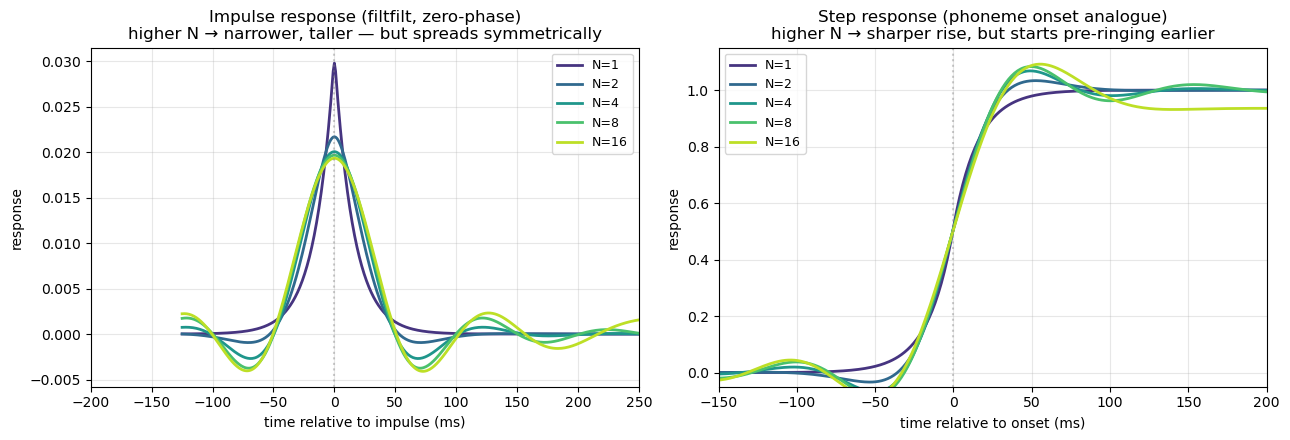

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Order comparison in the time domain
# ═══════════════════════════════════════════════════════════════════════════════
# Sharper frequency response costs you something — wider time-domain spread.
# This is the time–frequency uncertainty principle: you can't have both an
# infinitely sharp filter AND an infinitely fast impulse response.
#
# Higher order = the filter "remembers" each input sample for longer, so
# the impulse response has more area away from t=0 and the step response
# takes longer to settle.

duration = 0.5
n_imp    = int(duration * SR)
impulse  = np.zeros(n_imp); impulse[n_imp//4] = 1.0
t_imp    = (np.arange(n_imp) - n_imp//4) / SR * 1000

step_in  = np.zeros(n_imp)
step_in[n_imp//2:] = 1.0
t_step_o = (np.arange(n_imp) - n_imp//2) / SR * 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A — impulse responses
ax = axes[0]
for n, c in zip(orders_to_compare, colors_order):
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')
    y = scipy.signal.sosfiltfilt(sos, impulse)
    ax.plot(t_imp, y, lw=2, color=c, label=f'N={n}')
ax.axvline(0, color='gray', ls=':', alpha=0.4)
ax.set_xlim(-200, 250)
ax.set_xlabel('time relative to impulse (ms)')
ax.set_ylabel('response')
ax.set_title('Impulse response (filtfilt, zero-phase)\n'
             'higher N → narrower, taller — but spreads symmetrically')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# Panel B — step responses
ax = axes[1]
for n, c in zip(orders_to_compare, colors_order):
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')
    y   = scipy.signal.sosfiltfilt(sos, step_in)
    ax.plot(t_step_o, y, lw=2, color=c, label=f'N={n}')
ax.axvline(0, color='gray', ls=':', alpha=0.4)
ax.set_xlim(-150, 200); ax.set_ylim(-0.05, 1.15)
ax.set_xlabel('time relative to onset (ms)')
ax.set_ylabel('response')
ax.set_title('Step response (phoneme onset analogue)\n'
             'higher N → sharper rise, but starts pre-ringing earlier')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — The trade-off, in numbers
# ═══════════════════════════════════════════════════════════════════════════════
# Quantify what each order N gives you and what it costs.

print(f"\n{'order N':>9} {'rolloff (single)':>18} {'rolloff (filtfilt)':>20} "
      f"{'trans-width':>14} {'imp resp 1%-1% width':>22}")
print("  " + "-" * 86)

for n in orders_to_compare:
    sos = scipy.signal.iirfilter(n, F_CUT/(SR/2), btype='lowpass', output='sos')

    # frequency-domain numbers
    w, h = scipy.signal.sosfreqz(sos, worN=8192, fs=SR)
    mag_db = 20*np.log10(np.abs(h)+1e-15)
    f_minus1  = w[np.argmax(mag_db < -1)]
    f_minus40 = w[np.argmax(mag_db < -40)]
    trans_width = f_minus40 - f_minus1
    rolloff_single   = 6 * n
    rolloff_filtfilt = 12 * n

    # time-domain: width where impulse response stays above 1% of its peak
    imp_resp = scipy.signal.sosfiltfilt(sos, impulse)
    peak     = np.abs(imp_resp).max()
    above1pc = np.where(np.abs(imp_resp) > 0.01 * peak)[0]
    width_ms = (above1pc[-1] - above1pc[0]) / SR * 1000 if len(above1pc) else 0.0

    print(f"  N={n:<5} {rolloff_single:>10} dB/oct  "
          f"{rolloff_filtfilt:>10} dB/oct  "
          f"{trans_width:>10.1f} Hz  "
          f"{width_ms:>16.0f} ms")

print("""
   Reading the table:
   • rolloff (single)    — slope of the dB curve in CELL 7B, single-pass apply
   • rolloff (filtfilt)  — what you actually get because filtfilt squares |H|
   • trans-width         — Hz between −1 dB and −40 dB; small = sharp knee
   • imp resp 1%-1% width — total time the filter "remembers" any input sample

   Sharper frequency selectivity (smaller trans-width) costs you wider time-
   domain spread (larger imp resp width). This is unavoidable physics — it's
   the time-frequency uncertainty principle. Picking the right N means picking
   the right point on this trade-off curve for your application.

   Pipeline choice (N=4 with filtfilt):
   • 48 dB/oct effective rolloff       — clean separation of phoneme rate from noise
   • ~100 ms 1%-impulse width          — matches phoneme duration (no over-spread)
   • passband flat to ~5 Hz            — phoneme rate (5–10 Hz) preserved exactly

   Going higher (N=8 or 16):
   • +marginal noise rejection         (already at −80 dB by 50 Hz with N=4)
   • but ~150–250 ms impulse spread    — would smear neighboring phonemes
   • diminishing returns               in this application

   Going lower (N=1 or 2):
   • compact impulse response          (~50 ms, very tight)
   • but only −6 to −12 dB at 30 Hz    — leaks envelope noise back in
   • would give back most of the gain over the boxcar baseline
""")


  order N   rolloff (single)   rolloff (filtfilt)    trans-width   imp resp 1%-1% width
  --------------------------------------------------------------------------------------
  N=1              6 dB/oct          12 dB/oct       404.2 Hz               146 ms
  N=2             12 dB/oct          24 dB/oct        89.9 Hz               209 ms
  N=4             24 dB/oct          48 dB/oct        23.1 Hz               305 ms
  N=8             48 dB/oct          96 dB/oct         8.6 Hz               416 ms
  N=16            96 dB/oct         192 dB/oct         3.8 Hz               499 ms

   Reading the table:
   • rolloff (single)    — slope of the dB curve in CELL 7B, single-pass apply
   • rolloff (filtfilt)  — what you actually get because filtfilt squares |H|
   • trans-width         — Hz between −1 dB and −40 dB; small = sharp knee
   • imp resp 1%-1% width — total time the filter "remembers" any input sample

   Sharper frequency selectivity (smaller trans-width) costs you wider t